In [1]:
from enum import Enum
from typing import NamedTuple

import numpy as np
import pandas as pd
import uproot

In [2]:
class Benchmark(Enum):
    SM = 0
    W = 1
    NEG_W = 2
    WW = 3
    NEG_WW = 4


class EFTCoefficients(NamedTuple):
    cwl2: float
    cpwl2: float


# Map the benchmark names to their couplings (CWL2, CPWL2)
benchmarks_to_eftcoeffs = {
    Benchmark.SM: EFTCoefficients(0.0, 0.0),
    Benchmark.W: EFTCoefficients(15.2, 0.1),
    Benchmark.NEG_W: EFTCoefficients(-15.2, 0.2),
    Benchmark.WW: EFTCoefficients(0.3, 15.1),
    Benchmark.NEG_WW: EFTCoefficients(0.4, -15.3),
}

benchmarks_to_name = {
    Benchmark.SM: "sm",
    Benchmark.W: "w",
    Benchmark.NEG_W: "neg_w",
    Benchmark.WW: "ww",
    Benchmark.NEG_WW: "neg_ww",
}

In [3]:
# load the data
f = uproot.open("~/Downloads/combined_samples.root")["Events"]
array = f.arrays(library="pd") # load the data as a pandas DataFrame

datasets = {
    benchmark: array[array["sampling_benchmark_id"] == benchmark.value]
    for benchmark in Benchmark
}

In [4]:
datasets[Benchmark.SM]

,pt_j1,delta_phi_jj,met,weight_sm,weight_w,weight_neg_w,weight_ww,weight_neg_ww,weight_morphing_basis_vector_5,weight_scale_corr_nuisance_param_0_down,...,weight_scale_muf_nuisance_param_0_up,weight_scale_mur_nuisance_param_0_down,weight_scale_mur_nuisance_param_0_up,nuisance_a_scale_mur_nuisance_param_0,nuisance_b_scale_mur_nuisance_param_0,nuisance_a_scale_muf_nuisance_param_0,nuisance_b_scale_muf_nuisance_param_0,nuisance_a_scale_corr_nuisance_param_0,nuisance_b_scale_corr_nuisance_param_0,sampling_benchmark_id
5,99.818286,2.782542,13.493930,4.510509e-09,7.139709e-10,1.158871e-08,9.574421e-10,1.447325e-08,4.360400e-09,4.868199e-09,...,4.193920e-09,4.510509e-09,4.510509e-09,0.0,0.0,-0.074544,0.001770,-0.074544,0.001770,0
6,62.126001,-0.985939,21.649132,4.510509e-09,4.143774e-09,4.049669e-08,2.697580e-08,1.987838e-09,2.168096e-08,4.505374e-09,...,4.488061e-09,4.510509e-09,4.510509e-09,0.0,0.0,-0.001925,-0.003064,-0.001925,-0.003064,0
23,77.344027,2.007129,7.495510,4.510509e-09,1.173375e-10,1.826580e-08,1.669374e-09,2.958433e-08,6.039918e-09,4.613838e-09,...,4.392978e-09,4.510509e-09,4.510509e-09,0.0,0.0,-0.024526,-0.001876,-0.024526,-0.001876,0
26,52.201756,1.967798,6.117868,4.510509e-09,1.933084e-09,8.864491e-09,4.755157e-10,2.261123e-08,1.086316e-08,4.373625e-09,...,4.598785e-09,4.510509e-09,4.510509e-09,0.0,0.0,0.025100,-0.005718,0.025100,-0.005718,0
31,42.756030,1.088585,8.648267,4.510509e-09,1.352636e-09,9.510925e-09,1.013789e-09,1.035827e-08,3.956365e-09,4.481439e-09,...,4.494394e-09,4.510509e-09,4.510509e-09,0.0,0.0,0.001443,-0.005022,0.001443,-0.005022,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
249110,98.064010,2.105830,7.709686,4.510509e-09,7.761416e-11,1.577033e-08,8.069746e-09,4.974187e-08,1.592404e-08,4.935962e-09,...,4.143419e-09,4.510509e-09,4.510509e-09,0.0,0.0,-0.087513,0.002625,-0.087513,0.002625,0
249114,91.641377,-0.811802,24.030281,4.510509e-09,1.627715e-08,6.856360e-08,5.758220e-08,2.596799e-08,5.688354e-08,4.621485e-09,...,4.388196e-09,4.510509e-09,4.510509e-09,0.0,0.0,-0.025899,-0.001593,-0.025899,-0.001593,0
249118,38.316615,-1.075046,8.785938,4.510509e-09,5.856291e-10,1.524782e-08,1.941419e-08,4.131883e-10,2.085591e-09,4.327837e-09,...,4.638245e-09,4.510509e-09,4.510509e-09,0.0,0.0,0.034634,-0.006708,0.034634,-0.006708,0
249131,147.375831,0.816388,17.479188,4.510509e-09,1.545785e-07,2.767620e-07,9.648058e-08,1.827145e-07,2.307987e-08,5.054195e-09,...,4.056487e-09,4.510509e-09,4.510509e-09,0.0,0.0,-0.109951,0.003858,-0.109951,0.003858,0


In [ ]:
feature_list = ["pt_j1", "delta_phi_jj", "met"]

def phase_space_cuts(df: pd.DataFrame) -> pd.DataFrame:
    return df[(df["pt_j1"] < 500) & (df["met"] < 100)]

def prepare(datasets: dict[Benchmark, pd.DataFrame], benchmark: Benchmark) -> pd.DataFrame:
    assert benchmark != Benchmark.SM, "The benchmark should not be the SM, as it is used as the reference distribution."
    SM = phase_space_cuts(datasets[Benchmark.SM])
    B = phase_space_cuts(datasets[benchmark])
    df = pd.concat([SM, B], ignore_index=True)
    df["weights"] = np.where(
        df["sampling_benchmark_id"] == benchmark.value, df[f"weight_{benchmarks_to_name[benchmark]}"], df["weight_sm"]
    )
    df["train_labels"] = np.where(df["sampling_benchmark_id"] == benchmark.value, 1, 0).astype("int")
    return df.astype('float32')


df = prepare(datasets, Benchmark.WW)
df

,pt_j1,delta_phi_jj,met,weight_sm,weight_w,weight_neg_w,weight_ww,weight_neg_ww,weight_morphing_basis_vector_5,weight_scale_corr_nuisance_param_0_down,...,weight_scale_mur_nuisance_param_0_up,nuisance_a_scale_mur_nuisance_param_0,nuisance_b_scale_mur_nuisance_param_0,nuisance_a_scale_muf_nuisance_param_0,nuisance_b_scale_muf_nuisance_param_0,nuisance_a_scale_corr_nuisance_param_0,nuisance_b_scale_corr_nuisance_param_0,sampling_benchmark_id,weights,train_labels
0,99.818283,2.782542,13.493931,4.510509e-09,7.139709e-10,1.158871e-08,9.574420e-10,1.447325e-08,4.360400e-09,4.868199e-09,...,4.510509e-09,0.0,0.0,-0.074544,0.001770,-0.074544,0.001770,0.0,4.510509e-09,0.0
1,62.125999,-0.985939,21.649132,4.510509e-09,4.143774e-09,4.049669e-08,2.697580e-08,1.987838e-09,2.168096e-08,4.505374e-09,...,4.510509e-09,0.0,0.0,-0.001925,-0.003064,-0.001925,-0.003064,0.0,4.510509e-09,0.0
2,77.344025,2.007129,7.495510,4.510509e-09,1.173375e-10,1.826580e-08,1.669374e-09,2.958433e-08,6.039918e-09,4.613838e-09,...,4.510509e-09,0.0,0.0,-0.024526,-0.001876,-0.024526,-0.001876,0.0,4.510509e-09,0.0
3,52.201756,1.967798,6.117867,4.510509e-09,1.933084e-09,8.864491e-09,4.755157e-10,2.261123e-08,1.086316e-08,4.373625e-09,...,4.510509e-09,0.0,0.0,0.025100,-0.005718,0.025100,-0.005718,0.0,4.510509e-09,0.0
4,42.756031,1.088585,8.648268,4.510509e-09,1.352636e-09,9.510925e-09,1.013788e-09,1.035827e-08,3.956365e-09,4.481439e-09,...,4.510509e-09,0.0,0.0,0.001443,-0.005022,0.001443,-0.005022,0.0,4.510509e-09,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
89934,110.874420,-1.503195,40.348080,2.426207e-09,5.861368e-08,1.220160e-07,2.170063e-07,1.489405e-07,3.397937e-07,2.472023e-09,...,2.426207e-09,0.0,0.0,-0.019957,-0.001250,-0.019957,-0.001250,3.0,2.170063e-07,1.0
89935,455.683075,-1.252158,83.713364,2.126314e-11,5.851308e-08,6.686253e-08,2.170063e-07,2.218294e-07,3.337471e-07,2.341550e-11,...,2.126314e-11,0.0,0.0,-0.093495,0.002928,-0.093495,0.002928,3.0,2.170063e-07,1.0
89936,310.365662,0.930153,15.814495,3.499038e-10,2.440627e-07,2.795757e-07,2.170063e-07,2.366198e-07,3.286448e-08,3.934801e-10,...,3.499038e-10,0.0,0.0,-0.113770,0.003602,-0.113770,0.003602,3.0,2.170063e-07,1.0
89937,235.020920,-1.009668,8.423273,5.174332e-12,5.216097e-08,5.512991e-08,2.170063e-07,2.211794e-07,2.373904e-07,5.334103e-12,...,5.174332e-12,0.0,0.0,-0.030823,-0.000413,-0.030823,-0.000413,3.0,2.170063e-07,1.0


In [ ]:
from nsbi_common_utils.training import density_ratio_trainer


trainer = density_ratio_trainer(
    dataset=df,
    weights=df["weights"],
    training_labels=df["train_labels"],
    features=feature_list,
    features_scaling=feature_list,
    sample_name=["SM", "WW"],
    output_name="SM_vs_WW",
    path_to_figures="plots/",
    path_to_models="models/",
)

trainer.train(
    hidden_layers=3,
    neurons=64,
    number_of_epochs=10,
    batch_size=1024,
    learning_rate=1e-3,
    scalerType="StandardScaler",
    ensemble_index=0,
)


2026-04-10 16:48:04 | INFO | Training Logs | Sum of weights of class 0: 0.00015489087672904134
2026-04-10 16:48:04 | INFO | Training Logs | Sum of weights of class 1: 0.0062102871015667915
2026-04-10 16:48:04 | INFO | Training Logs | Using swish activation function
GPU available: True (mps), used: True
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
/Users/pf4572/Desktop/repos/NSBI-workflow-tutorial/.venv/lib/python3.12/site-packages/pytorch_lightning/callbacks/model_checkpoint.py:881: Checkpoint directory /Users/pf4572/Desktop/repos/NSBI-workflow-tutorial/examples/madminer_dataset/checkpoints exists and is not empty.


┏━━━┳━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━┳━━━━━━━┳━━━━━━━┓
┃   ┃ Name ┃ Type       ┃ Params ┃ Mode  ┃ FLOPs ┃
┡━━━╇━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━╇━━━━━━━╇━━━━━━━┩
│ 0 │ mlp  │ Sequential │  8.6 K │ train │     0 │
│ 1 │ out  │ Linear     │     65 │ train │     0 │
└───┴──────┴────────────┴────────┴───────┴───────┘

Trainable params: 8.6 K                                                                                            
Non-trainable params: 0                                                                                            
Total params: 8.6 K                                                                                                
Total estimated model params size (MB): 0                                                                          
Modules in train mode: 8                                                                                           
Modules in eval mode: 0                                                                                            
Total FLOPs: 0

/Users/pf4572/Desktop/repos/NSBI-workflow-tutorial/.venv/lib/python3.12/site-packages/pytorch_lightning/utilities/_pytree.py:21: `isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.
/Users/pf4572/Desktop/repos/NSBI-workflow-tutorial/.venv/lib/python3.12/site-packages/pytorch_lightning/trainer/connectors/data_connector.py:434: The 'val_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=13` in the `DataLoader` to improve performance.
/Users/pf4572/Desktop/repos/NSBI-workflow-tutorial/.venv/lib/python3.12/site-packages/torch/utils/data/dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  super().__init__(loader)
/Users/pf4572/Desktop/repos/NSBI-workflow-tutorial/.venv/lib/python3.12/site-packages/pytorch_lightning/trainer/connectors/data_connector.py:43

Epoch    0 | lr = 1.000e-03 | val_loss = 0.677426 | 
Epoch    0 | lr = 1.000e-03 | val_loss = 0.101494 | 
Epoch    1 | lr = 1.000e-03 | train_loss = 0.313897 | val_loss = 0.097914 | 
Epoch    2 | lr = 1.000e-03 | train_loss = 0.098499 | val_loss = 0.095856 | 
Epoch    3 | lr = 1.000e-03 | train_loss = 0.096164 | val_loss = 0.094441 | 
Epoch    4 | lr = 1.000e-03 | train_loss = 0.094517 | val_loss = 0.093848 | 
Epoch    5 | lr = 1.000e-03 | train_loss = 0.093503 | val_loss = 0.093560 | 
Epoch    6 | lr = 1.000e-03 | train_loss = 0.093150 | val_loss = 0.093556 | 
Epoch    7 | lr = 1.000e-03 | train_loss = 0.093016 | val_loss = 0.093760 | 
Epoch    8 | lr = 1.000e-03 | train_loss = 0.092918 | val_loss = 0.093366 | 


...

Epoch    9 | lr = 1.000e-03 | train_loss = 0.092928 | val_loss = 0.093443 | 


W0410 16:48:09.372000 60778 torch/onnx/_internal/exporter/_registration.py:110] torchvision is not installed. Skipping torchvision::nms
W0410 16:48:09.373000 60778 torch/onnx/_internal/exporter/_registration.py:110] torchvision is not installed. Skipping torchvision::roi_align
W0410 16:48:09.373000 60778 torch/onnx/_internal/exporter/_registration.py:110] torchvision is not installed. Skipping torchvision::roi_pool
/opt/homebrew/Cellar/python@3.12/3.12.13/Frameworks/Python.framework/Versions/3.12/lib/python3.12/copyreg.py:99: FutureWarning: `isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.
  return cls.__new__(cls, *args)
The model version conversion is not supported by the onnxscript version converter and fallback is enabled. The model will be converted using the onnx C API (target version: 17).


[torch.onnx] Obtain model graph for `DensityRatioLightning([...]` with `torch.export.export(..., strict=False)`...
[torch.onnx] Obtain model graph for `DensityRatioLightning([...]` with `torch.export.export(..., strict=False)`... ✅
[torch.onnx] Run decompositions...
[torch.onnx] Run decompositions... ✅
[torch.onnx] Translate the graph into ONNX...
[torch.onnx] Translate the graph into ONNX... ✅
[torch.onnx] Optimize the ONNX graph...
[torch.onnx] Optimize the ONNX graph... ✅


/Users/pf4572/Desktop/repos/NSBI-workflow-tutorial/.venv/lib/python3.12/site-packages/onnxruntime/capi/onnxruntime_inference_collection.py:123: UserWarning: Specified provider 'CUDAExecutionProvider' is not in available provider names.Available providers: 'CoreMLExecutionProvider, AzureExecutionProvider, CPUExecutionProvider'
  warnings.warn(
/Users/pf4572/Desktop/repos/NSBI-workflow-tutorial/.venv/lib/python3.12/site-packages/onnxruntime/capi/onnxruntime_inference_collection.py:123: UserWarning: Specified provider 'CUDAExecutionProvider' is not in available provider names.Available providers: 'CoreMLExecutionProvider, AzureExecutionProvider, CPUExecutionProvider'
  warnings.warn(


<Figure size 800x600 with 0 Axes>

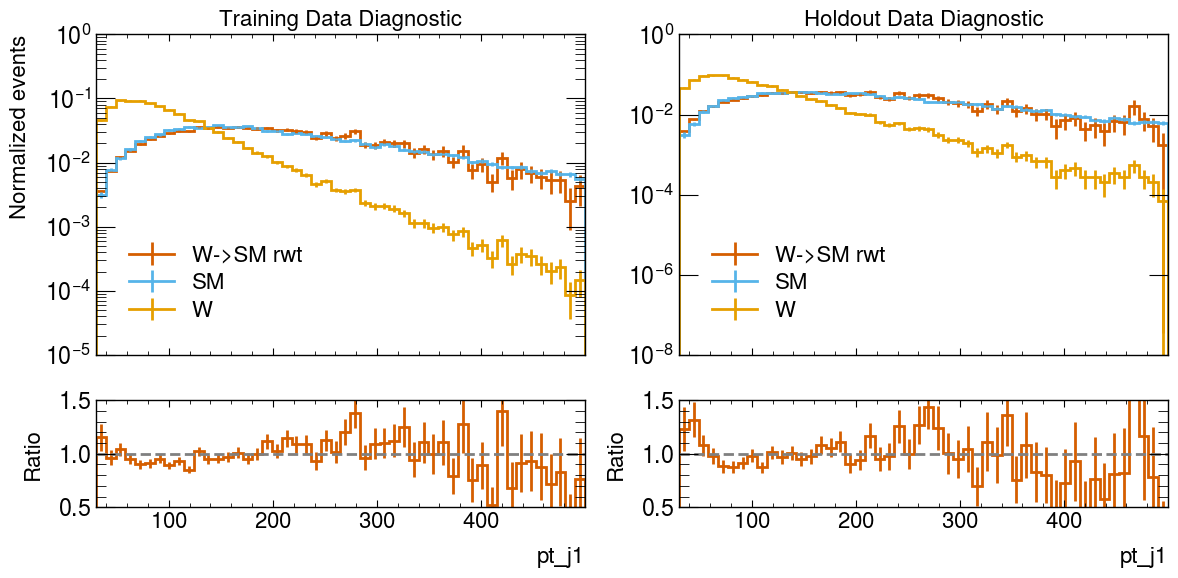

<Figure size 800x600 with 0 Axes>

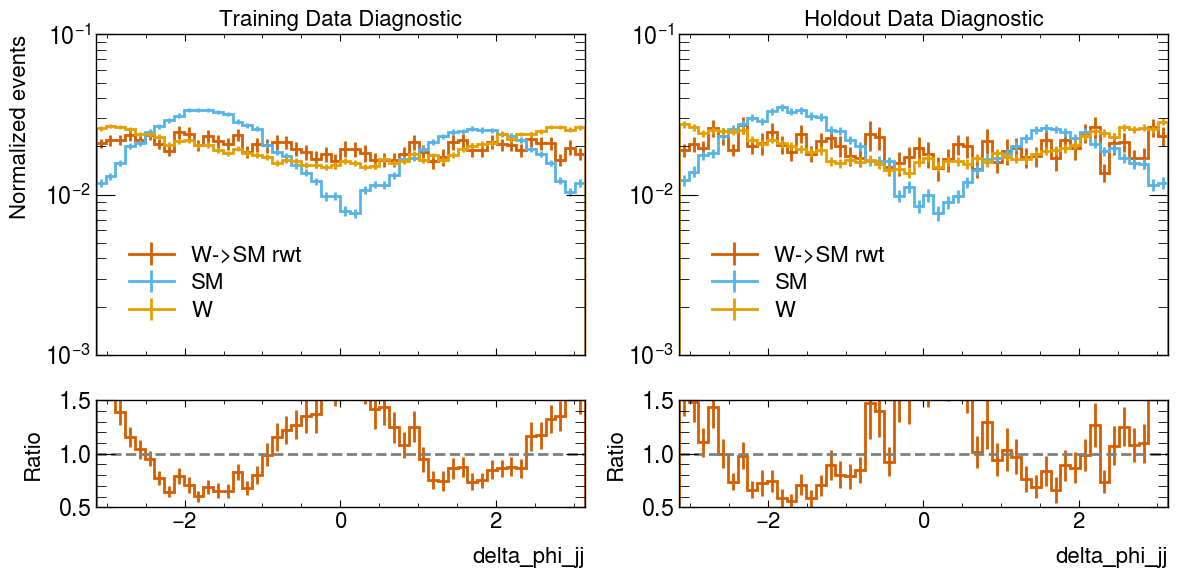

<Figure size 800x600 with 0 Axes>

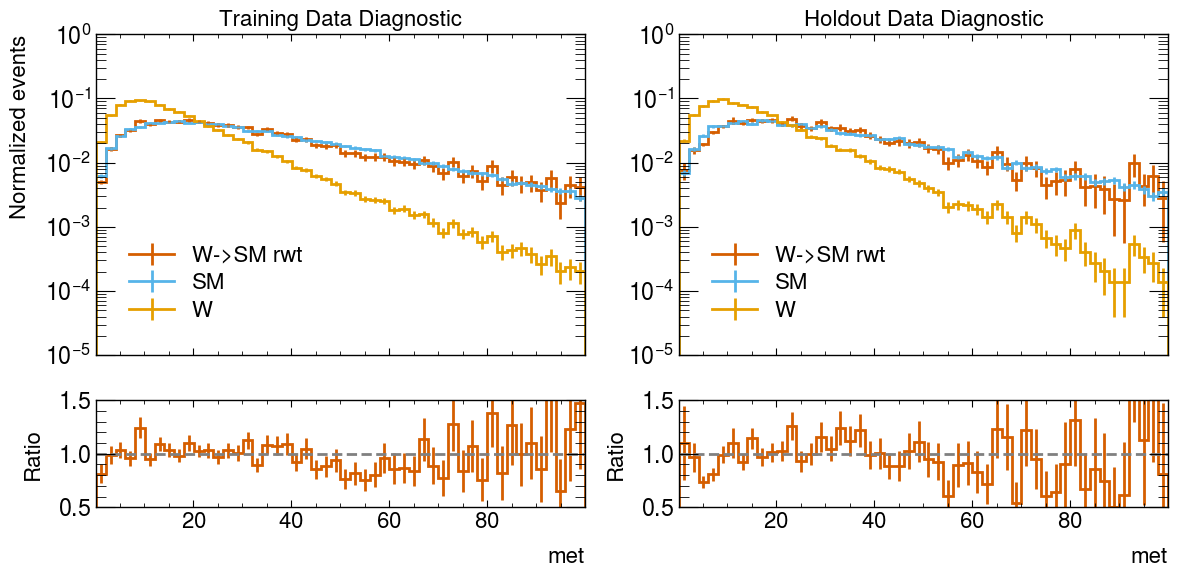

<Figure size 800x600 with 0 Axes>

In [43]:
# Inspect the trainer object

trainer.make_reweighted_plots(feature_list, "log", 50)

In [ ]:
import nsbi_common_utils


path_to_trained_models = "models/"
ensemble_index = 0

path_to_saved_scaler = f"{path_to_trained_models}model_scaler{ensemble_index}.bin"
path_to_saved_model = f"{path_to_trained_models}model{ensemble_index}.onnx"

scaler, model_NN = nsbi_common_utils.training.load_trained_model(path_to_saved_model, path_to_saved_scaler)
score_pred = nsbi_common_utils.training.predict_with_model(datasets[Benchmark.SM][feature_list].astype('float32'), scaler, model_NN)
ratio_pred = nsbi_common_utils.training.convert_score_to_ratio(score_pred)

/Users/pf4572/Desktop/repos/NSBI-workflow-tutorial/.venv/lib/python3.12/site-packages/onnxruntime/capi/onnxruntime_inference_collection.py:123: UserWarning: Specified provider 'CUDAExecutionProvider' is not in available provider names.Available providers: 'CoreMLExecutionProvider, AzureExecutionProvider, CPUExecutionProvider'
  warnings.warn(


In [48]:
ratio_pred

array([ 8.398516, 11.230877,  6.054995, ...,  4.894229, 56.961197,
        5.604535], dtype=float32)

In [50]:
truth = datasets[Benchmark.SM]["weight_ww"] / datasets[Benchmark.SM]["weight_sm"]

mse = np.mean((np.log(truth) - np.log(ratio_pred))**2)
mse

4.0794432500126705